# Data Integrity Findings

## 1. Setup

### 1.1 Load Libraries

In [1]:
from pathlib import Path
import sys
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

### 1.2 Locate the repository root and define the expected Data Integrity paths.

In [23]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name.lower() == "notebooks" else cwd

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RAW_DIR = REPO_ROOT / "data" / "raw"

CUSTOMERS_PATH = RAW_DIR / "collections_queue_sep2026.csv"
WHATSAPP_PATH = RAW_DIR / "whatsapp_collections_history.csv"

print("Repository   :", REPO_ROOT)
print("Raw directory:", RAW_DIR)
print("Customers    :", CUSTOMERS_PATH)
print("Whatsapp :", WHATSAPP_PATH)

Repository   : C:\Users\beelt\Documents\collections_case_candidate
Raw directory: C:\Users\beelt\Documents\collections_case_candidate\data\raw
Customers    : C:\Users\beelt\Documents\collections_case_candidate\data\raw\collections_queue_sep2026.csv
Whatsapp : C:\Users\beelt\Documents\collections_case_candidate\data\raw\whatsapp_collections_history.csv


## 2. Load raw sources

In [24]:
for path in [CUSTOMERS_PATH, INTERACTIONS_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

customers = pd.read_csv(CUSTOMERS_PATH, low_memory=False)
whatsapp = pd.read_csv(INTERACTIONS_PATH, low_memory=False)

datasets = {
    "customers": customers,
    "whatsapp": whatsapp,
}

print("customers   :", customers.shape)
print("whatsapp:", whatsapp.shape)

customers   : (10658, 10)
whatsapp: (75406, 17)


## 3. Dataset inventory

In [10]:
inventory = pd.DataFrame([
    {
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "unique_customers": df["customer_id"].nunique(dropna=True),
        "duplicate_rows": int(df.duplicated().sum()),
        "missing_cells": int(df.isna().sum().sum()),
        "memory_mb": df.memory_usage(deep=True).sum() / 1024**2,
    }
    for name, df in datasets.items()
])

display(inventory.round(3))

,dataset,rows,columns,unique_customers,duplicate_rows,missing_cells,memory_mb
0,customers,10658,10,10658,0,0,2.257
1,whatsapp,75406,17,11724,0,0,34.875


In [7]:
for name, df in datasets.items():
    display(Markdown(f"### `{name}` — columns and physical types"))
    info = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "missing": df.isna().sum().values,
        "unique": [df[c].nunique(dropna=True) for c in df.columns],
    })
    display(info)

### `customers` — columns and physical types

,column,dtype,non_null,missing,unique
0,customer_id,str,10658,0,10658
1,in_collections_since,str,10658,0,89
2,days_past_due_on_2026-09-01,int64,10658,0,60
3,outstanding_balance_brl,float64,10658,0,9250
4,monthly_salary_brl,float64,10658,0,617
5,payday_day_of_month,int64,10658,0,7
6,n_prior_transactions,int64,10658,0,40
7,account_age_months,int64,10658,0,40
8,days_since_last_app_login,int64,10658,0,165
9,state_uf,str,10658,0,27


### `whatsapp` — columns and physical types

,column,dtype,non_null,missing,unique
0,message_id,str,75406,0,75406
1,customer_id,str,75406,0,11724
2,sent_at,str,75406,0,39466
3,template,str,75406,0,4
4,n_msgs_last_14d,int64,75406,0,11
5,days_past_due,int64,75406,0,60
6,outstanding_balance_brl,float64,75406,0,11510
7,monthly_salary_brl,float64,75406,0,628
8,payday_day_of_month,int64,75406,0,7
9,n_prior_transactions,int64,75406,0,40


# Part I — Customers


In [14]:
def find_first_existing(df, candidates):
    lookup = {str(c).lower(): c for c in df.columns}
    for candidate in candidates:
        if candidate.lower() in lookup:
            return lookup[candidate.lower()]
    return None

CUSTOMER_KEY = find_first_existing(
    customers,
    ["customer_id", "id_cliente", "cliente_id", "id_customer"]
)

print("Detected customer key:", CUSTOMER_KEY)

Detected customer key: customer_id


## 4. Customers — grain and key integrity

<!-- Revisar esta seção depois -->

Verifica se a chave do cliente é válida e respeita o grão de uma linha por cliente, avaliando valores únicos, missing e duplicados.

In [15]:
if CUSTOMER_KEY is None:
    print("Customer key not detected automatically. Set CUSTOMER_KEY manually.")
else:
    customer_key_summary = pd.Series({
        "rows": len(customers),
        "unique_non_null_keys": customers[CUSTOMER_KEY].nunique(dropna=True),
        "missing_keys": customers[CUSTOMER_KEY].isna().sum(),
        "duplicate_non_null_keys": customers[CUSTOMER_KEY].dropna().duplicated().sum(),
        "key_is_unique": customers[CUSTOMER_KEY].dropna().is_unique,
        "grain_1_row_per_customer": (
            customers[CUSTOMER_KEY].notna().all()
            and customers[CUSTOMER_KEY].is_unique
        )
    }, name="value").to_frame()
    display(customer_key_summary)

,value
rows,10658
unique_non_null_keys,10658
missing_keys,0
duplicate_non_null_keys,0
key_is_unique,True
grain_1_row_per_customer,True


## 5. Customers — missingness

<!-- Revisar esta seção depois -->

Analisa a quantidade e o percentual de valores missing por coluna, destacando visualmente as colunas mais afetadas.

In [16]:
def missing_profile(df):
    out = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": df.isna().mean().values * 100,
    })
    return out.sort_values(["missing_pct", "missing_count"], ascending=False)

customers_missing = missing_profile(customers)
display(customers_missing.round(2))

plot_df = customers_missing[customers_missing["missing_count"] > 0].head(25).sort_values("missing_pct")
if not plot_df.empty:
    plt.figure(figsize=(9, max(4, len(plot_df) * .3)))
    plt.barh(plot_df["column"], plot_df["missing_pct"])
    plt.xlabel("Missing (%)")
    plt.title("Customers — missingness")
    plt.tight_layout()
    plt.show()

,column,missing_count,missing_pct
0,customer_id,0,0.0
1,in_collections_since,0,0.0
2,days_past_due_on_2026-09-01,0,0.0
3,outstanding_balance_brl,0,0.0
4,monthly_salary_brl,0,0.0
5,payday_day_of_month,0,0.0
6,n_prior_transactions,0,0.0
7,account_age_months,0,0.0
8,days_since_last_app_login,0,0.0
9,state_uf,0,0.0


## 6. Customers — suspicious missing tokens

<!-- Revisar esta seção depois -->

Verifica valores textuais que podem representar missings ou valores sentinelas/suspeitos nas colunas.

In [17]:
CANONICAL_MISSING_TOKENS = {
    "", "null", "nulo", "none", "n/a", "na", "nan", "<na>"
}
SUSPICIOUS_TOKENS = {
    "-", "--", "sem informacao", "não informado", "nao informado", "999", "9999"
}

def normalize_text_for_check(x):
    if pd.isna(x):
        return None
    return str(x).strip().lower()

def token_findings(df):
    rows = []
    for col in df.columns:
        s = df[col]
        if not (pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s)):
            continue
        norm = s.map(normalize_text_for_check)
        for kind, tokens in [
            ("canonical_missing_token", CANONICAL_MISSING_TOKENS),
            ("suspicious_token", SUSPICIOUS_TOKENS),
        ]:
            mask = norm.isin(tokens)
            if mask.any():
                rows.append({
                    "column": col,
                    "finding": kind,
                    "affected_rows": int(mask.sum()),
                    "affected_pct": float(mask.mean() * 100),
                    "examples": list(s[mask].dropna().astype(str).unique()[:5]),
                })
    return pd.DataFrame(rows)

customers_tokens = token_findings(customers)
display(customers_tokens)

""


## 7. Customers — string / encoding integrity

<!-- Revisar esta seção depois -->

Verifica problemas de integridade e formatação nas colunas de texto.

In [18]:
def string_findings(df):
    rows = []
    for col in df.select_dtypes(include=["object", "string"]).columns:
        s = df[col].dropna().astype(str)
        if s.empty:
            continue

        leading_trailing = s.ne(s.str.strip())
        tabs = s.str.contains(r"\t", regex=True)
        control = s.str.contains(r"[\x00-\x08\x0b\x0c\x0e-\x1f]", regex=True)
        replacement = s.str.contains("�|ï¿½", regex=True)

        for finding, mask in [
            ("leading_or_trailing_whitespace", leading_trailing),
            ("tab_character", tabs),
            ("control_character", control),
            ("replacement_or_encoding_character", replacement),
        ]:
            if mask.any():
                rows.append({
                    "column": col,
                    "finding": finding,
                    "affected_rows": int(mask.sum()),
                    "examples": list(s[mask].unique()[:5])
                })
    return pd.DataFrame(rows)

customers_strings = string_findings(customers)
display(customers_strings)

""


## 8. Customers — numeric integrity

<!-- Revisar esta seção depois -->

Verifica problemas de integridade em variáveis numéricas, identificando valores infinitos e colunas com mistura de números e textos.

In [20]:
def numeric_findings(df):
    rows = []
    for col in df.columns:
        s = df[col]

        if pd.api.types.is_numeric_dtype(s):
            vals = pd.to_numeric(s, errors="coerce")
            pos_inf = np.isposinf(vals).sum()
            neg_inf = np.isneginf(vals).sum()

            if pos_inf:
                rows.append({"column": col, "finding": "positive_infinity", "affected_rows": int(pos_inf)})
            if neg_inf:
                rows.append({"column": col, "finding": "negative_infinity", "affected_rows": int(neg_inf)})

        elif pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
            nonnull = s.dropna().astype(str).str.strip()
            if len(nonnull):
                parsed = pd.to_numeric(nonnull, errors="coerce")
                parse_ratio = parsed.notna().mean()
                if 0 < parse_ratio < 1:
                    rows.append({
                        "column": col,
                        "finding": "mixed_numeric_and_text_representation",
                        "affected_rows": int(parsed.isna().sum()),
                        "numeric_parse_pct": float(parse_ratio * 100),
                    })
    return pd.DataFrame(rows)

customers_numeric = numeric_findings(customers)
display(customers_numeric)

""


## 9. Customers — categorical representation

<!-- Revisar esta seção depois -->

Verifica inconsistências de padronização nas variáveis categóricas, identificando categorias duplicadas por espaços ou diferenças entre maiúsculas e minúsculas.

In [21]:
def categorical_findings(df, max_unique=100):
    rows = []
    for col in df.select_dtypes(include=["object", "string"]).columns:
        s = df[col].dropna().astype(str)
        if s.empty or s.nunique() > max_unique:
            continue

        stripped = s.str.strip()
        lower = stripped.str.lower()

        if s.nunique() != stripped.nunique():
            rows.append({
                "column": col,
                "finding": "whitespace_category_variants",
                "raw_unique": s.nunique(),
                "normalized_unique": stripped.nunique(),
            })

        if stripped.nunique() != lower.nunique():
            rows.append({
                "column": col,
                "finding": "case_category_variants",
                "raw_unique": stripped.nunique(),
                "normalized_unique": lower.nunique(),
            })

    return pd.DataFrame(rows)

customers_categories = categorical_findings(customers)
display(customers_categories)

""


# Part II — Whatsapp


In [27]:
MESSAGE_KEY = find_first_existing(
    whatsapp,
    ["message_id", "id_interacao", "interaction_id", "id_mensagem"]
)

WHATSAPP_CUSTOMER_KEY = find_first_existing(
    whatsapp,
    ["customer_id", "id_cliente", "cliente_id", "id_customer"]
)

print("Detected whatsapp key:", MESSAGE_KEY)
print("Detected customer FK     :", WHATSAPP_CUSTOMER_KEY)

Detected whatsapp key: message_id
Detected customer FK     : customer_id


## 10. Whatsapp — grain and key integrity

<!-- Revisar esta seção depois -->

Verifica se o grão das interações é de uma linha por mensagem e analisa a relação com clientes, identificando chaves únicas, missing e repetições de customer_id

In [29]:
if MESSAGE_KEY is None:
    print("Interaction/message key not detected automatically. Set MESSAGE_KEY manually.")
else:
    whatsapp_key_summary = pd.Series({
        "rows": len(whatsapp),
        "unique_non_null_message_keys": whatsapp[MESSAGE_KEY].nunique(dropna=True),
        "missing_message_keys": whatsapp[MESSAGE_KEY].isna().sum(),
        "duplicate_non_null_message_keys": whatsapp[MESSAGE_KEY].dropna().duplicated().sum(),
        "message_key_is_unique": whatsapp[MESSAGE_KEY].dropna().is_unique,
        "grain_1_row_per_interaction": (
            whatsapp[MESSAGE_KEY].notna().all()
            and whatsapp[MESSAGE_KEY].is_unique
        )
    }, name="value").to_frame()
    display(whatsapp_key_summary)

if WHATSAPP_CUSTOMER_KEY:
    display(pd.Series({
        "interaction_rows": len(whatsapp),
        "unique_customers": whatsapp[WHATSAPP_CUSTOMER_KEY].nunique(dropna=True),
        "missing_customer_fk": whatsapp[WHATSAPP_CUSTOMER_KEY].isna().sum(),
        "repeated_customer_fk_rows": whatsapp[WHATSAPP_CUSTOMER_KEY].dropna().duplicated().sum(),
    }, name="value").to_frame())

,value
rows,75406
unique_non_null_message_keys,75406
missing_message_keys,0
duplicate_non_null_message_keys,0
message_key_is_unique,True
grain_1_row_per_interaction,True


,value
interaction_rows,75406
unique_customers,11724
missing_customer_fk,0
repeated_customer_fk_rows,63682


## 11. Whatsapp — missingness

<!-- Revisar esta seção depois -->

Analisa a quantidade e o percentual de valores missing nas interações, destacando visualmente as colunas mais afetadas.

In [31]:
whatsapp_missing = missing_profile(whatsapp)
display(whatsapp_missing.round(2))

plot_df = whatsapp_missing[whatsapp_missing["missing_count"] > 0].head(25).sort_values("missing_pct")
if not plot_df.empty:
    plt.figure(figsize=(9, max(4, len(plot_df) * .3)))
    plt.barh(plot_df["column"], plot_df["missing_pct"])
    plt.xlabel("Missing (%)")
    plt.title("Interactions — missingness")
    plt.tight_layout()
    plt.show()

,column,missing_count,missing_pct
0,message_id,0,0.0
1,customer_id,0,0.0
2,sent_at,0,0.0
3,template,0,0.0
4,n_msgs_last_14d,0,0.0
5,days_past_due,0,0.0
6,outstanding_balance_brl,0,0.0
7,monthly_salary_brl,0,0.0
8,payday_day_of_month,0,0.0
9,n_prior_transactions,0,0.0


## 12. Whatsapp — suspicious missing tokens

<!-- Revisar esta seção depois -->

Verifica valores textuais nas interações que podem representar missings ou valores sentinelas/suspeitos.

In [32]:
whatsapp_tokens = token_findings(whatsapp)
display(whatsapp_tokens)

,column,finding,affected_rows,affected_pct,examples
0,interaction,canonical_missing_token,45201,59.943506,[none]


então "none" significa algo como “nenhuma interação ocorreu”, e não “valor ausente”.

## 13. Whatsapp — string / encoding integrity

Verifica problemas de formatação e integridade nas colunas de texto das interações, como espaços extras, tabs, caracteres invisíveis e problemas de encoding.

In [33]:
whatsapp_strings = string_findings(whatsapp)
display(whatsapp_strings)

""


## 14. Whatsapp — numeric integrity

Verifica problemas de integridade nas variáveis numéricas das interações, identificando valores infinitos e colunas com mistura de números e textos.

In [35]:
whatsapp_numeric = numeric_findings(whatsapp)
display(whatsapp_numeric)

""


## 15. Whatsapp — categorical representation

Verifica inconsistências de padronização nas variáveis categóricas do WhatsApp, como categorias duplicadas por espaços ou diferenças entre maiúsculas e minúsculas.

In [36]:
whatsapp_categories = categorical_findings(whatsapp)
display(whatsapp_categories)

""


# Part III — Semantic / representation inventory

Este é um inventário simplificado das variáveis, baseado nos nomes das colunas e em suas representações físicas nos dados.


In [37]:
def infer_ds_semantic_type(col, series):
    name = str(col).lower()

    if re.search(r"(^|_)id$|^id_|_id_|customer_id|cliente_id|message_id", name):
        return "identifier"
    if re.search(r"saldo|valor|amount|renda|receita|limite|divida|debito|recuper", name):
        return "monetary"
    if re.search(r"pct|percent|percentage|taxa|rate|ratio", name):
        return "percentage"
    if re.search(r"(^data$|^data_|_data$|date|datetime|timestamp|_at$)", name):
        return "datetime"
    if re.search(r"^is_|^has_|^flag_|_flag$|indicador|regularizou", name):
        return "boolean"
    if pd.api.types.is_integer_dtype(series):
        return "integer"
    if pd.api.types.is_numeric_dtype(series):
        return "numeric"
    return "categorical/string"

semantic_inventory = []

for dataset_name, df in datasets.items():
    for col in df.columns:
        semantic_inventory.append({
            "dataset": dataset_name,
            "column": col,
            "physical_dtype": str(df[col].dtype),
            "suggested_semantic_type": infer_ds_semantic_type(col, df[col]),
            "missing_pct": df[col].isna().mean() * 100,
            "nunique": df[col].nunique(dropna=True),
        })

semantic_inventory = pd.DataFrame(semantic_inventory)
display(semantic_inventory.round(2))

,dataset,column,physical_dtype,suggested_semantic_type,missing_pct,nunique
0,customers,customer_id,str,identifier,0.0,10658
1,customers,in_collections_since,str,categorical/string,0.0,89
2,customers,days_past_due_on_2026-09-01,int64,integer,0.0,60
3,customers,outstanding_balance_brl,float64,numeric,0.0,9250
4,customers,monthly_salary_brl,float64,numeric,0.0,617
5,customers,payday_day_of_month,int64,integer,0.0,7
6,customers,n_prior_transactions,int64,integer,0.0,40
7,customers,account_age_months,int64,integer,0.0,40
8,customers,days_since_last_app_login,int64,integer,0.0,165
9,customers,state_uf,str,categorical/string,0.0,27


# Part IV — Cross-table integrity


## 16. Key dtype compatibility

In [40]:
if CUSTOMER_KEY and WHATSAPP_CUSTOMER_KEY:
    key_compatibility = pd.Series({
        "customers_key": CUSTOMER_KEY,
        "customers_dtype": str(customers[CUSTOMER_KEY].dtype),
        "whatsapp_fk": WHATSAPP_CUSTOMER_KEY,
        "whatsapp_dtype": str(whatsapp[WHATSAPP_CUSTOMER_KEY].dtype),
        "same_physical_dtype": (
            str(customers[CUSTOMER_KEY].dtype)
            == str(whatsapp[WHATSAPP_CUSTOMER_KEY].dtype)
        ),
    }, name="value").to_frame()
    display(key_compatibility)

,value
customers_key,customer_id
customers_dtype,str
whatsapp_fk,customer_id
whatsapp_dtype,str
same_physical_dtype,True


## 17. Customers without interactions

In [41]:
if CUSTOMER_KEY and WHATSAPP_CUSTOMER_KEY:
    customer_ids = set(customers[CUSTOMER_KEY].dropna())
    whatsapp_customer_ids = set(whatsapp[WHATSAPP_CUSTOMER_KEY].dropna())

    customers_without_whatsapp = customer_ids - whatsapp_customer_ids

    print("Distinct customers without whatsapp:", len(customers_without_whatsapp))
    display(
        pd.DataFrame({CUSTOMER_KEY: list(customers_without_whatsapp)}).head(50)
    )

Distinct customers without whatsapp: 5276


,customer_id
0,C014591
1,C014521
2,C013435
3,C012894
4,C013300
5,C015075
6,C015805
7,C013803
8,C016524
9,C013847


## 18. Interactions without a known customer — orphan foreign keys

In [45]:
if CUSTOMER_KEY and WHATSAPP_CUSTOMER_KEY:

    # IDs existentes em cada base
    customer_ids = set(
        customers[CUSTOMER_KEY].dropna()
    )

    whatsapp_ids = set(
        whatsapp[WHATSAPP_CUSTOMER_KEY].dropna()
    )

    # IDs presentes no WhatsApp, mas inexistentes em Customers
    orphan_customer_ids = whatsapp_ids - customer_ids

    # Linhas do WhatsApp pertencentes a esses IDs
    orphan_row_mask = whatsapp[WHATSAPP_CUSTOMER_KEY].isin(
        orphan_customer_ids
    )

    referential_summary = pd.Series({
        "distinct_orphan_customer_ids": len(orphan_customer_ids),
        "whatsapp_rows_with_orphan_customer": int(orphan_row_mask.sum()),
        "whatsapp_rows_with_missing_customer_fk": int(
            whatsapp[WHATSAPP_CUSTOMER_KEY].isna().sum()
        ),
    }, name="value").to_frame()

    display(referential_summary)

    # Exemplos
    if orphan_row_mask.any():
        display(
            whatsapp.loc[orphan_row_mask].head(50)
        )

,value
distinct_orphan_customer_ids,6342
whatsapp_rows_with_orphan_customer,42059
whatsapp_rows_with_missing_customer_fk,0


,message_id,customer_id,sent_at,template,n_msgs_last_14d,days_past_due,outstanding_balance_brl,monthly_salary_brl,payday_day_of_month,n_prior_transactions,account_age_months,days_since_last_app_login,state_uf,delivery_status,interaction,paid_within_72h,amount_paid_brl
0,M0000001,C001934,2026-06-01 09:18,pix_link,0,1,867.63,3000.0,5,2,4,44,PB,delivered,none,0,0.00
1,M0000002,C007836,2026-06-01 09:18,friendly_reminder,0,1,790.21,3260.0,30,3,3,9,RJ,delivered,read,0,0.00
2,M0000003,C004887,2026-06-01 09:48,friendly_reminder,0,1,1030.00,3120.0,5,2,6,5,PA,delivered,none,0,0.00
3,M0000004,C009207,2026-06-01 09:53,friendly_reminder,0,1,250.94,1200.0,30,11,11,26,SP,delivered,read,0,0.00
4,M0000005,C003478,2026-06-01 09:54,friendly_reminder,0,1,511.52,1740.0,10,2,1,23,SP,delivered,read,0,0.00
5,M0000006,C010842,2026-06-01 09:56,pix_link,0,1,675.11,3680.0,10,8,11,11,PE,delivered,replied,0,0.00
6,M0000007,C005040,2026-06-01 10:06,friendly_reminder,0,1,467.81,2050.0,10,2,4,7,GO,delivered,none,0,0.00
7,M0000008,C003731,2026-06-01 10:16,friendly_reminder,0,1,293.86,2510.0,1,2,11,5,SC,delivered,read,0,0.00
8,M0000009,C009101,2026-06-01 10:21,friendly_reminder,0,1,655.47,1750.0,5,1,4,8,AC,delivered,clicked_link,0,0.00
9,M0000010,C003340,2026-06-01 10:22,friendly_reminder,0,1,454.38,1520.0,5,10,10,27,PR,delivered,read,0,0.00


## 19. Common columns 


In [46]:
common_columns = sorted(set(customers.columns) & set(whatsapp.columns))

print("Common columns:", len(common_columns))
display(pd.DataFrame({"column": common_columns}))

Common columns: 8


,column
0,account_age_months
1,customer_id
2,days_since_last_app_login
3,monthly_salary_brl
4,n_prior_transactions
5,outstanding_balance_brl
6,payday_day_of_month
7,state_uf


## 20. Relationship cardinality

For a valid `1:N` relationship:
- the customer master key should be unique;
- the whatsapp foreign key may repeat;
- every non-null whatsapp foreign key should ideally resolve to a customer master record.


,n_interactions
count,11724.000000
mean,6.431764
std,3.751953
min,1.000000
25%,3.000000
50%,6.000000
75%,9.000000
max,21.000000


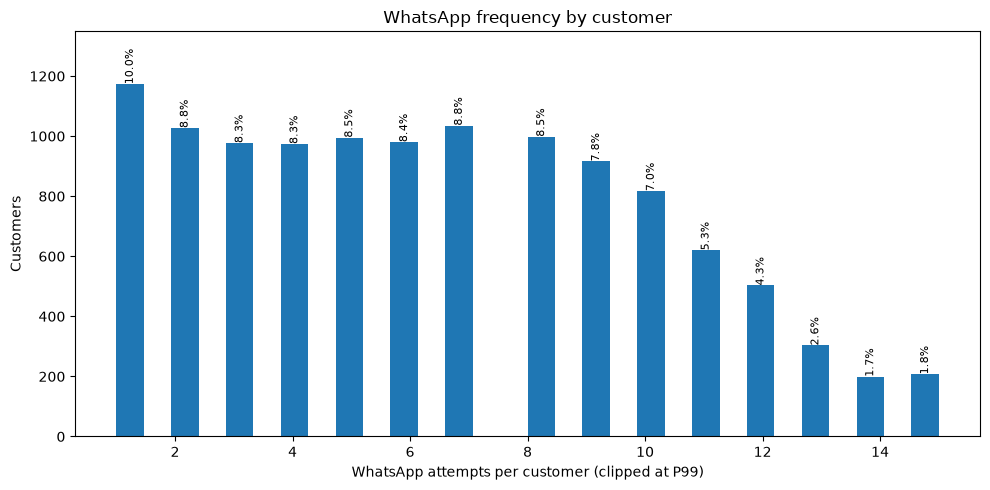

In [48]:
if CUSTOMER_KEY and WHATSAPP_CUSTOMER_KEY:
    whatsapp_counts = (
        whatsapp
        .dropna(subset=[WHATSAPP_CUSTOMER_KEY])
        .groupby(WHATSAPP_CUSTOMER_KEY)
        .size()
        .rename("n_interactions")
    )

    display(whatsapp_counts.describe().to_frame())

    # Limita visualmente valores extremos no P99
    clipped = whatsapp_counts.clip(
        upper=whatsapp_counts.quantile(.99)
    )

    plt.figure(figsize=(10, 5))

    counts, bins, patches = plt.hist(
        clipped,
        bins=30
    )

    # Percentual de clientes em cada barra
    total_customers = len(clipped)

    for count, patch in zip(counts, patches):
        if count > 0:
            pct = count / total_customers * 100

            plt.text(
                patch.get_x() + patch.get_width() / 2,
                count,
                f"{pct:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90
            )

    plt.xlabel("WhatsApp attempts per customer (clipped at P99)")
    plt.ylabel("Customers")
    plt.title("WhatsApp frequency by customer")

    # Espaço extra para os labels
    plt.ylim(0, max(counts) * 1.15)

    plt.tight_layout()
    plt.show()

# Part V — Consolidated findings

In [49]:
finding_frames = []

def append_findings(df, dataset, domain):
    if df is not None and not df.empty:
        x = df.copy()
        x.insert(0, "dataset", dataset)
        x.insert(1, "domain", domain)
        finding_frames.append(x)

append_findings(customers_tokens, "customers", "missing_tokens")
append_findings(customers_strings, "customers", "strings_encoding")
append_findings(customers_numeric, "customers", "numeric")
append_findings(customers_categories, "customers", "categorical")

append_findings(whatsapp_tokens, "whatsapp", "missing_tokens")
append_findings(whatsapp_strings, "whatsapp", "strings_encoding")
append_findings(whatsapp_numeric, "whatsapp", "numeric")
append_findings(whatsapp_categories, "whatsapp", "categorical")

all_findings = (
    pd.concat(finding_frames, ignore_index=True, sort=False)
    if finding_frames else pd.DataFrame()
)

print("Finding records:", len(all_findings))
display(all_findings)

Finding records: 1


,dataset,domain,column,finding,affected_rows,affected_pct,examples
0,whatsapp,missing_tokens,interaction,canonical_missing_token,45201,59.943506,[none]


então "none" significa algo como “nenhuma interação ocorreu”, e não “valor ausente”.

## 21. Findings by dataset and domain

,dataset,domain,finding_records
0,whatsapp,missing_tokens,1


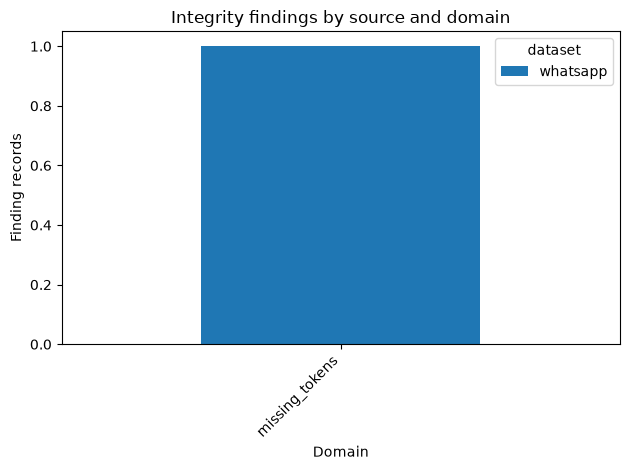

In [51]:
if not all_findings.empty:
    findings_summary = (
        all_findings.groupby(["dataset", "domain"])
        .size()
        .rename("finding_records")
        .reset_index()
    )
    display(findings_summary)

    pivot = findings_summary.pivot(
        index="domain", columns="dataset", values="finding_records"
    ).fillna(0)
    pivot.plot(kind="bar", title="Integrity findings by source and domain")
    plt.ylabel("Finding records")
    plt.xlabel("Domain")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No findings produced by the lightweight notebook checks.")

## 22. Integration readiness summary



In [52]:
readiness = {}

if CUSTOMER_KEY:
    readiness["customers_key_missing"] = int(customers[CUSTOMER_KEY].isna().sum())
    readiness["customers_key_duplicates"] = int(
        customers[CUSTOMER_KEY].dropna().duplicated().sum()
    )

if MESSAGE_KEY:
    readiness["whatsapp_key_missing"] = int(whatsapp[MESSAGE_KEY].isna().sum())
    readiness["whatsapp_key_duplicates"] = int(
        whatsapp[MESSAGE_KEY].dropna().duplicated().sum()
    )

if CUSTOMER_KEY and WHATSAPP_CUSTOMER_KEY:
    readiness["whatsapp_customer_fk_missing"] = int(
        whatsapp[WHATSAPP_CUSTOMER_KEY].isna().sum()
    )
    readiness["orphan_customer_ids"] = int(len(orphan_customer_ids))
    readiness["orphan_whatsapp_rows"] = int(orphan_row_mask.sum())
    readiness["customers_without_whatsapp"] = int(len(customers_without_whatsapp))

readiness_df = pd.Series(readiness, name="count").to_frame()
display(readiness_df)

,count
customers_key_missing,0
customers_key_duplicates,0
whatsapp_key_missing,0
whatsapp_key_duplicates,0
whatsapp_customer_fk_missing,0
orphan_customer_ids,6342
orphan_whatsapp_rows,42059
customers_without_whatsapp,5276


In [53]:
blocking = []

for metric in [
    "customers_key_missing",
    "customers_key_duplicates",
    "whatsapp_key_missing",
    "whatsapp_key_duplicates",
    "orphan_customer_ids",
]:
    if readiness.get(metric, 0) > 0:
        blocking.append(metric)

if blocking:
    status = "REVIEW BEFORE INTEGRATION"
else:
    status = "STRUCTURAL KEY / REFERENTIAL CHECKS PASSED"

display(Markdown(f"""
### Integration readiness

**Status:** `{status}`

Potential structural blockers detected: **{len(blocking)}**

`{blocking if blocking else "none"}`

This gate only covers the integrity checks represented in this notebook. It does not replace business/domain Data Quality validation.
"""))


### Integration readiness

**Status:** `REVIEW BEFORE INTEGRATION`

Potential structural blockers detected: **1**

`['orphan_customer_ids']`

This gate only covers the integrity checks represented in this notebook. It does not replace business/domain Data Quality validation.
